# Monitoring-length analyses

This notebook evaluates how PPGR prediction and participant PC-score estimation change with monitoring length. Day indices count ordered observed calendar dates; gaps in recording do not add day indices.

## Notebook flow

1. Fit expanding one- to eleven-day training windows and predict the same final three-day block within a fourteen-day record.
2. Compare full-model and population-only prediction learning curves.
3. Refit phenotype models over one- to fourteen-day windows and convert their BLUPs to reference scaling.
4. Compare window-specific PC scores with overlapping fourteen-day and uncapped-record references.
5. Use one shared phenotype model to compare four non-overlapping three-day windows with their respective eleven-day complements, then assess score agreement and bias.

## Outputs

CSV files written to `Results/`:

| File | Contents |
| --- | --- |
| `monitoring_length_learning_curve_full_vs_fixed.csv` | Prediction metrics by training duration, PPGR outcome, and full versus fixed-effects prediction. |
| `PC_score_minimum_days_analysis.csv` | PC1/PC2 ICCs and correlations by monitoring duration and reference fit. |

The PC-score agreement figure is saved as `Figures/panel_3_PC1_PC2_recoverability.svg`. Three-day/complement diagnostics are displayed in the notebook. The optional reference-audit CSV export is commented out.

## 1. Setup

Resolve project paths, import the monitoring-window utilities, and load the common prepared meal-level dataset.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, Code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "Code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import xgboost as xgb
from mmer import MixedEffectEstimator
from sklearn.model_selection import BaseCrossValidator, GroupKFold
from tqdm import tqdm

In [3]:
from utils import (
    DATE_COL,
    SUBJECT_COL,
    build_design_mats,
    derive_pc_basis,
    fit_training_fold,
    infer_blups_from_frozen_model,
    load_and_prepare_data,
    make_xgb,
    project_blups_to_pcs,
)

In [4]:
meta_data, data, id_to_subject_key, clusters = load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

print(f"Prepared {len(data):,} meals from {data['subject_key'].nunique():,} participants.")
# Preserve the entire prepared record before any analysis-specific date cap.
data_uncapped = data.copy(deep=True)


data shape : (54987, 133)
Prepared 54,987 meals from 992 participants.


## 2. Expanding-window prediction

In [5]:
class ExpandingWindowLastKDaysOut(BaseCrossValidator):
    """
    Expanding-window within-person CV with a FIXED validation block (last k_last days).

    Two tiers, decided per subject:
      * validation-eligible : n_days >= min_days  -> gets a val block (last k_last days)
                              AND an expanding train prefix.
      * short (n_days < min_days) -> NEVER validated. Handled by short_subject_policy:
            "exclude"    : dropped from both train and val.
            "train_only" : contributes rows to TRAINING only (first min(d, n_days) days).

    Validation eligibility is computed ONCE => the val set is identical across all splits.
    """
    def __init__(self, train_days_list, k_last=3, min_days=10,
                 time_col="eaten_at", embargo=pd.Timedelta("0h"),
                 short_subject_policy="exclude", min_val_rows=1):
        self.train_days_list = list(train_days_list)
        self.k_last = int(k_last)
        self.min_days = int(min_days)                 # required length to be VALIDATED
        self.time_col = time_col
        self.embargo = embargo
        assert short_subject_policy in ("exclude", "train_only")
        self.short_subject_policy = short_subject_policy
        self.min_val_rows = int(min_val_rows)
        if self.min_days <= self.k_last:
            raise ValueError("min_days must exceed k_last (need room to train, not just validate).")

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.train_days_list)

    def _subject_structure(self, X, groups):
        groups = np.asarray(groups)
        times = pd.to_datetime(X[self.time_col].values)
        info = {}
        for g in np.unique(groups):
            rows = np.where(groups == g)[0]
            r_times = times[rows]
            order = np.argsort(r_times)
            rows, r_times = rows[order], r_times[order]
            r_days = pd.to_datetime(pd.Series(r_times)).dt.normalize().values
            _, inv = np.unique(r_days, return_inverse=True)   # row -> day index
            n_days = int(inv.max()) + 1
            info[g] = dict(rows=rows, r_times=r_times, inv=inv, n_days=n_days)
        return info

    def _classify_subjects(self, info):
        """Decide ONCE: who is validation-eligible vs short. Keeps val block constant."""
        val_eligible, short, excluded = {}, {}, {}
        for g, s in info.items():
            if s["n_days"] >= self.min_days:
                # enough days; also check the val block actually has rows
                val_day_idxs = np.arange(s["n_days"] - self.k_last, s["n_days"])
                n_val_rows = int(np.isin(s["inv"], val_day_idxs).sum())
                if n_val_rows >= self.min_val_rows:
                    val_eligible[g] = s
                else:
                    excluded[g] = f"n_val_rows={n_val_rows} < min_val_rows={self.min_val_rows}"
            else:
                # short subject
                if self.short_subject_policy == "train_only":
                    short[g] = s
                else:
                    excluded[g] = f"n_days={s['n_days']} < min_days={self.min_days} (excluded)"
        self.val_eligible_subjects_ = list(val_eligible)
        self.train_only_subjects_   = list(short)
        self.excluded_subjects_     = excluded
        return val_eligible, short

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("groups must be provided")
        if not isinstance(X, pd.DataFrame) or self.time_col not in X.columns:
            raise ValueError("X must be a DataFrame with a datetime column named time_col")

        info = self._subject_structure(X, groups)
        val_eligible, short = self._classify_subjects(info)

        for d in self.train_days_list:
            train_all, val_all = [], []

            # ---- validated subjects: val block + expanding, embargoed train ----
            for g, s in val_eligible.items():
                rows, r_times, inv, n_days = s["rows"], s["r_times"], s["inv"], s["n_days"]

                val_day_idxs = np.arange(n_days - self.k_last, n_days)
                val_mask = np.isin(inv, val_day_idxs)

                n_train_days = min(d, n_days - self.k_last)          # cap => no val overlap
                train_mask = np.isin(inv, np.arange(0, n_train_days))

                train_rows, train_times = rows[train_mask], r_times[train_mask]

                # two-sided embargo, same logic as LeavePercentTimeOut
                if self.embargo > pd.Timedelta(0) and val_mask.any():
                    left  = r_times[val_mask].min() - self.embargo
                    right = r_times[val_mask].max() + self.embargo
                    keep = (train_times < left) | (train_times > right)
                    train_rows = train_rows[keep]

                val_all.append(rows[val_mask])
                if len(train_rows):
                    train_all.append(train_rows)

            # ---- short subjects: TRAIN ONLY, no val block, no embargo needed ----
            for g, s in short.items():
                rows, inv, n_days = s["rows"], s["inv"], s["n_days"]
                n_train_days = min(d, n_days)        # use all their days up to the window
                train_mask = np.isin(inv, np.arange(0, n_train_days))
                if train_mask.any():
                    train_all.append(rows[train_mask])

            yield np.concatenate(train_all), np.concatenate(val_all)

In [6]:
import os
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# --- parallelism config: keep N_PARALLEL_FITS * CORES_PER_FIT <= physical cores ---
N_PARALLEL_FITS = 5   # number of models fitted at a time
CORES_PER_FIT   = 6   # cores allocated to each fit (xgboost threads)

train_days_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
K_LAST = 3
cv = ExpandingWindowLastKDaysOut(
    train_days_list, k_last=K_LAST,
    time_col="eaten_at", embargo=pd.Timedelta("6h"),
    short_subject_policy="exclude", min_days=14
)

####### process data

# keep at most 14 days per participant
data = data_uncapped.loc[
    data_uncapped.groupby("subject_key")["eaten_date"]
        .rank(method="dense") <= 14
].copy().reset_index(drop=True)

clusters = data["subject_key"].reset_index(drop=True).copy()
groups = clusters.to_numpy()

# Verify that the validation set is identical across splits.
val_sets = [frozenset(v) for _, v in cv.split(data, groups=groups)]
assert all(v == val_sets[0] for v in val_sets), "val block drifted across splits!"

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]
remove_features    = ["demographics"]
mundlak_corr, interactions = False, [False]

# materialize splits once (generator can't be reused / pickled)
splits = list(cv.split(data, groups=groups))


def run_one(d, train_idx, val_idx):
    # prevent BLAS/OpenMP oversubscription inside each worker
    os.environ["OMP_NUM_THREADS"] = str(CORES_PER_FIT)

    print(f"\n[MMER_XGBoost] train on first {d} day(s), predict last {K_LAST} day(s) "
          f"| n_train={len(train_idx)} n_val={len(val_idx)}")

    X_train, X_val, Z_train, Z_val, y_train, y_val, \
        clusters_train, clusters_val, cluster_mapping, info_, _, _ = build_design_mats(
            data, train_idx, val_idx,
            target_outcome=prediction_metrics,
            apply_mundlak=mundlak_corr,
            use_interactions=interactions,
            population_z_scoring_features=True,
            remove_std_meals_from_training=True,
            remove_features=remove_features,
            random_slopes=["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"],
            population_z_scoring_outcome=True,
        )

    xgb_fe = make_xgb(njobs=CORES_PER_FIT)
    model  = MixedEffectEstimator(xgb_fe, max_iter=50, slq_steps=40, tol=1e-07, n_jobs=1)

    groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
    y_train_mmer = np.asarray(y_train)
    if y_train_mmer.ndim == 1:
        y_train_mmer = y_train_mmer.reshape(-1, 1)

    result = model.fit(X_train, y_train_mmer, groups_train_mmer,
                       random_slopes=([0, 1, 2, 3],))

    groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
    y_pred_full  = result.predict(X_val, groups=groups_val_mmer)
    y_pred_fixed = result.fixed_effects_model.predict(X_val)

    # ---- back to original units ----
    n = len(val_idx)
    y_val_z   = np.asarray(y_val).reshape(n, -1)
    y_pred_z  = np.asarray(y_pred_full).reshape(n, -1)
    y_fixed_z = np.asarray(y_pred_fixed).reshape(n, -1)

    if "outcome_mean" in info_:
        y_mean, y_std = np.asarray(info_["outcome_mean"]), np.asarray(info_["outcome_std"])
        y_true_o  = y_val_z   * y_std + y_mean
        y_pred_o  = y_pred_z  * y_std + y_mean
        y_fixed_o = y_fixed_z * y_std + y_mean
    else:
        y_true_o, y_pred_o, y_fixed_o = y_val_z, y_pred_z, y_fixed_z

    return d, dict(y_true=y_true_o, y_pred_full=y_pred_o, y_pred_fixed=y_fixed_o,
                   y_true_z=y_val_z, y_pred_full_z=y_pred_z, y_pred_fixed_z=y_fixed_z,
                  )


# run splits in parallel, N_PARALLEL_FITS at a time
results = Parallel(n_jobs=N_PARALLEL_FITS, prefer="processes")(
    delayed(run_one)(d, train_idx, val_idx)
    for d, (train_idx, val_idx) in zip(train_days_list, splits)
)

curve_records = dict(results)   # d -> dict(y_true, y_pred_full, y_pred_fixed)


[MMER_XGBoost] train on first 5 day(s), predict last 3 day(s) | n_train=15544 n_val=8740

[MMER_XGBoost] train on first 4 day(s), predict last 3 day(s) | n_train=12327 n_val=8740

[MMER_XGBoost] train on first 3 day(s), predict last 3 day(s) | n_train=9030 n_val=8740

[MMER_XGBoost] train on first 2 day(s), predict last 3 day(s) | n_train=5770 n_val=8740

[MMER_XGBoost] train on first 1 day(s), predict last 3 day(s) | n_train=2486 n_val=8740


Running MMER Framework | Fitting Model ...: 100%|██████████| 50/50 04:04



[MMER_XGBoost] train on first 6 day(s), predict last 3 day(s) | n_train=18916 n_val=8740


Finished: no further improvement!:  74%|███████▍  | 37/50 04:14         
Running MMER Framework | Fitting Model ...:  62%|██████▏   | 31/50 04:18


[MMER_XGBoost] train on first 7 day(s), predict last 3 day(s) | n_train=22255 n_val=8740


...

Finished: no further improvement!:  78%|███████▊  | 39/50 06:31         
Running MMER Framework | Fitting Model ...: 100%|██████████| 50/50 06:38



[MMER_XGBoost] train on first 9 day(s), predict last 3 day(s) | n_train=28285 n_val=8740

[MMER_XGBoost] train on first 10 day(s), predict last 3 day(s) | n_train=31291 n_val=8740


Finished: no further improvement!:  74%|███████▍  | 37/50 06:57         



[MMER_XGBoost] train on first 11 day(s), predict last 3 day(s) | n_train=34233 n_val=8740


Finished: no further improvement!:  72%|███████▏  | 36/50 07:52         
Finished: no further improvement!:  70%|███████   | 35/50 08:15         
Finished: no further improvement!:  68%|██████▊   | 34/50 08:58         
Finished: no further improvement!:  76%|███████▌  | 38/50 09:27         
Finished: no further improvement!:  54%|█████▍    | 27/50 06:58         


In [7]:
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

def _score(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return dict(r2=np.nan, rmse=np.nan, pearson=np.nan, n=int(m.sum()))
    return dict(
        r2      = r2_score(y_true[m], y_pred[m]),
        rmse    = mean_squared_error(y_true[m], y_pred[m]) ** 0.5,
        pearson = pearsonr(y_true[m], y_pred[m])[0],
        n       = int(m.sum()),)

def _global_vw(y_true, y_pred):
    m = np.isfinite(y_true).all(axis=1) & np.isfinite(y_pred).all(axis=1)
    if m.sum() < 2:
        return dict(r2=np.nan, rmse=np.nan, pearson=np.nan, n=int(m.sum()))
    r2 = r2_score(y_true[m], y_pred[m], multioutput="uniform_average")
    return dict(r2=r2, rmse=np.nan, pearson=np.nan, n=int(m.sum()))

rows = []
for d, rec in tqdm(curve_records.items()):
    for pred_kind, key in [("full", "y_pred_full"), ("fixed", "y_pred_fixed")]:
        for j, metric in enumerate(prediction_metrics):
            s = _score(rec["y_true"][:, j], rec[key][:, j])
            rows.append(dict(train_days=d, metric=metric, pred_kind=pred_kind, **s))
        g = _global_vw(rec["y_true"], rec[key])
        rows.append(dict(train_days=d, metric="global", pred_kind=pred_kind, **g))

learning_curve = pd.DataFrame(rows).sort_values(["metric", "pred_kind", "train_days"])
print(learning_curve.to_string(index=False))

100%|██████████| 11/11 [00:00<00:00, 92.90it/s]

 train_days        metric pred_kind       r2        rmse  pearson    n
          1   end_glucose     fixed 0.304203   15.076381 0.602480 8740
          2   end_glucose     fixed 0.395649   14.050779 0.638103 8740
          3   end_glucose     fixed 0.388468   14.134015 0.637218 8740
          4   end_glucose     fixed 0.388961   14.128317 0.636653 8740
          5   end_glucose     fixed 0.378892   14.244240 0.630310 8740
          6   end_glucose     fixed 0.379999   14.231545 0.633125 8740
          7   end_glucose     fixed 0.382021   14.208325 0.633171 8740
          8   end_glucose     fixed 0.390941   14.105408 0.642353 8740
          9   end_glucose     fixed 0.397577   14.028350 0.647772 8740
         10   end_glucose     fixed 0.393338   14.077623 0.645940 8740
         11   end_glucose     fixed 0.400443   13.994945 0.650652 8740
          1   end_glucose      full 0.284939   15.283658 0.578031 8740
          2   end_glucose      full 0.391702   14.096596 0.633124 8740
      

In [8]:
learning_curve.to_csv(RESULTS_DIR / "monitoring_length_learning_curve_full_vs_fixed.csv")

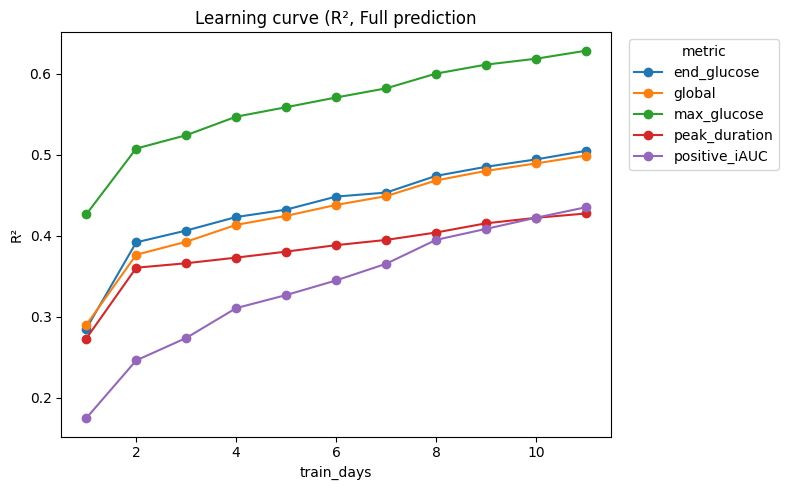

In [9]:
# learning_curve = pd.read_csv(RESULTS_DIR / "learning_curve_full_vs_fixed.csv")

import matplotlib.pyplot as plt

# keep only the "full" predictions
sub = learning_curve[(learning_curve["pred_kind"] == "full")]

fig, ax = plt.subplots(figsize=(8, 5))

for metric, g in sub.groupby("metric"):
    g = g.sort_values("train_days")
    ax.plot(g["train_days"], g["r2"], marker="o", label=metric)

ax.set_xlabel("train_days")
ax.set_ylabel("R²")
ax.set_title('Learning curve (R², Full prediction')
ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

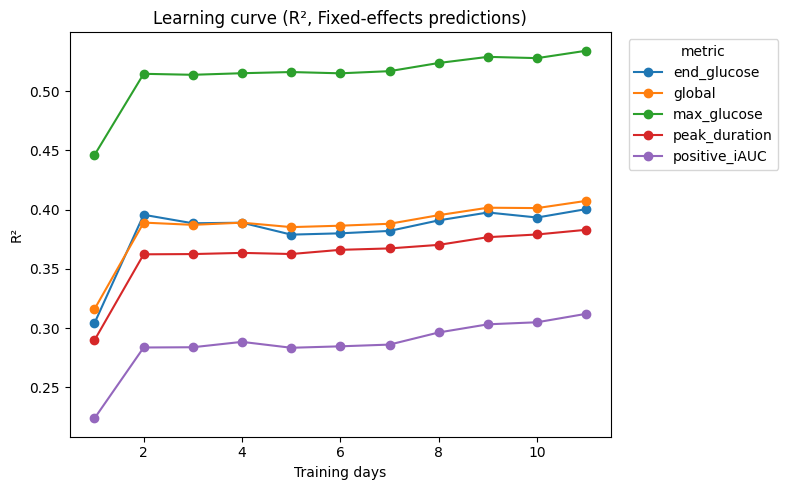

In [10]:
import matplotlib.pyplot as plt

# keep only the "full" predictions
sub = learning_curve[learning_curve["pred_kind"] == "fixed"]

fig, ax = plt.subplots(figsize=(8, 5))

for metric, g in sub.groupby("metric"):
    g = g.sort_values("train_days")
    ax.plot(g["train_days"], g["r2"], marker="o", label=metric)

ax.set_xlabel("Training days")
ax.set_ylabel("R²")
ax.set_title('Learning curve (R², Fixed-effects predictions)')
ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

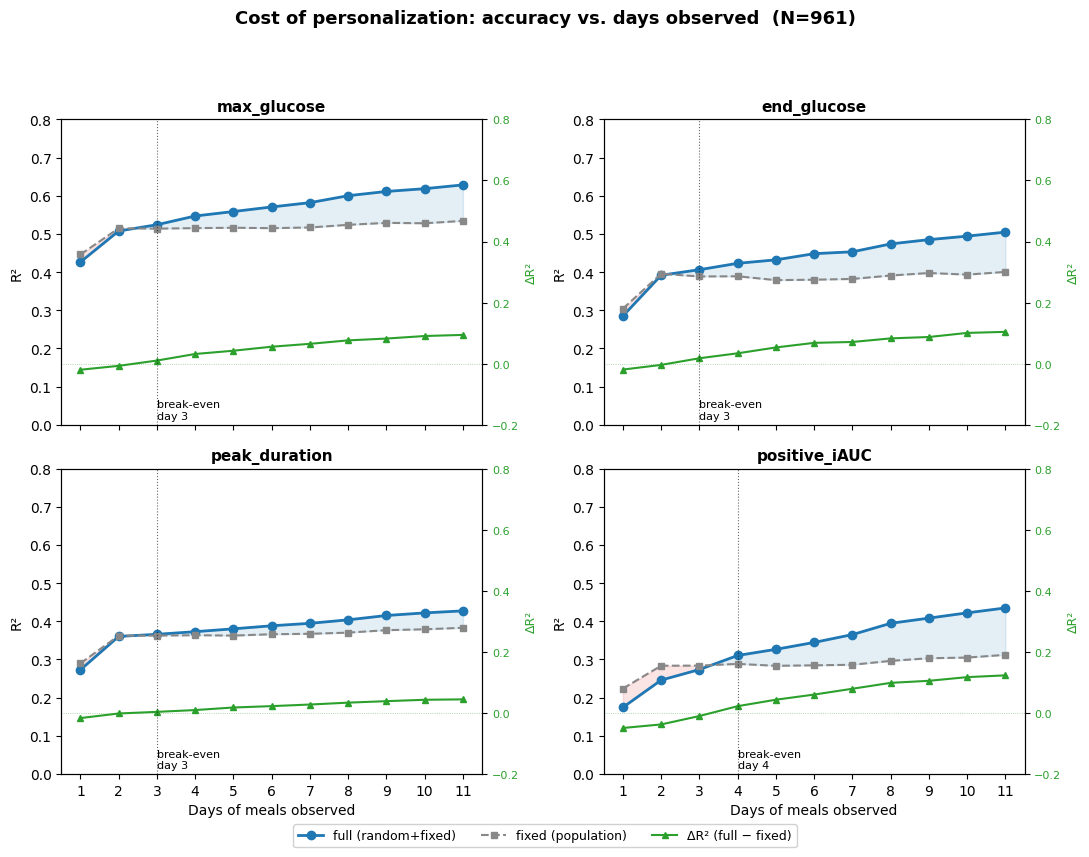

In [11]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["max_glucose", "end_glucose", "peak_duration", "positive_iAUC"]
C_FULL, C_FIX, C_DELTA = "#1f77b4", "#888888", "#2ca02c"

fig, axes = plt.subplots(2, 2, figsize=(11, 8.4), sharex=True)
handles_labels = None

for ax, m in zip(axes.ravel(), metrics):
    gf = (learning_curve[(learning_curve.metric == m) & (learning_curve.pred_kind == "full")]
          .sort_values("train_days"))
    gx = (learning_curve[(learning_curve.metric == m) & (learning_curve.pred_kind == "fixed")]
          .sort_values("train_days"))
    d, yf, yx = gf.train_days.values, gf.r2.values, gx.r2.values
    delta = yf - yx

    ax.fill_between(d, yx, yf, where=(yf >= yx), color=C_FULL, alpha=0.12, interpolate=True)
    ax.fill_between(d, yx, yf, where=(yf <  yx), color="#d62728", alpha=0.12, interpolate=True)
    l1, = ax.plot(d, yf, marker="o", color=C_FULL, lw=2, label="full (random+fixed)")
    l2, = ax.plot(d, yx, marker="s", ms=4, color=C_FIX, ls="--", lw=1.5, label="fixed (population)")

    # ΔR² on a secondary axis (its own scale — the gap is small vs the 0–0.8 range)
    ax2 = ax.twinx()
    l3, = ax2.plot(d, delta, marker="^", ms=4, color=C_DELTA, lw=1.5, label="ΔR² (full − fixed)")
    ax2.axhline(0, color=C_DELTA, lw=0.6, ls=":", alpha=0.5)
    ax2.set_ylim(-0.2, 0.8)
    ax2.set_ylabel("ΔR²", color=C_DELTA, fontsize=9)
    ax2.tick_params(axis="y", labelcolor=C_DELTA, labelsize=8)

    be = next((int(dd) for dd, a, b in zip(d, yf, yx) if a >= b), None)
    if be is not None:
        ax.axvline(be, color="k", lw=0.8, ls=":", alpha=0.6)
        ax.annotate(f"break-even\nday {be}", xy=(be, 0.01), fontsize=8, va="bottom")

    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.set_ylabel("R²")
    ax.set_xticks(d)
    ax.set_ylim([0, 0.8])
    ax.set_zorder(ax2.get_zorder() + 1)   # keep primary lines on top of the twin
    ax.patch.set_visible(False)
    if handles_labels is None:
        handles_labels = ([l1, l2, l3], [h.get_label() for h in (l1, l2, l3)])

for ax in axes[-1]:
    ax.set_xlabel("Days of meals observed")

fig.suptitle("Cost of personalization: accuracy vs. days observed  (N=961)",
             fontsize=13, fontweight="bold")
fig.legend(*handles_labels, ncol=3, fontsize=9, loc="lower center",
           bbox_to_anchor=(0.5, -0.025), framealpha=0.9
          )
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

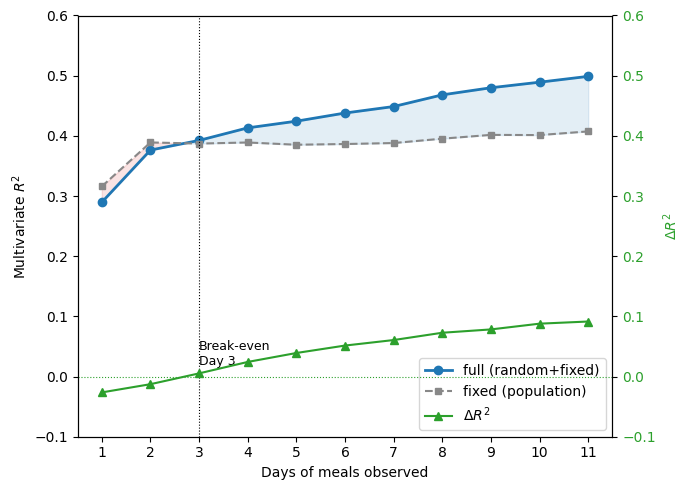

In [12]:
import matplotlib.pyplot as plt

C_FULL, C_FIX, C_DELTA = "#1f77b4", "#888888", "#2ca02c"

metric = "global"

gf = (learning_curve[
        (learning_curve.metric == metric) &
        (learning_curve.pred_kind == "full")
      ].sort_values("train_days"))

gx = (learning_curve[
        (learning_curve.metric == metric) &
        (learning_curve.pred_kind == "fixed")
      ].sort_values("train_days"))

d = gf.train_days.values
yf = gf.r2.values
yx = gx.r2.values
delta = yf - yx

fig, ax = plt.subplots(figsize=(7, 5))

# Shade gain/loss
ax.fill_between(d, yx, yf, where=(yf >= yx),
                color=C_FULL, alpha=0.12, interpolate=True)
ax.fill_between(d, yx, yf, where=(yf < yx),
                color="#d62728", alpha=0.12, interpolate=True)

# Main curves
l1, = ax.plot(d, yf, "-o", color=C_FULL, lw=2,
              label="full (random+fixed)")
l2, = ax.plot(d, yx, "--s", ms=5, color=C_FIX, lw=1.5,
              label="fixed (population)")

ax.set_xlabel("Days of meals observed")
ax.set_ylabel(r"Multivariate $R^2$")
ax.set_xticks(d)
ax.set_ylim(-0.1, 0.6)

# Secondary axis: ΔR²
ax2 = ax.twinx()
l3, = ax2.plot(d, delta, "-^", color=C_DELTA, lw=1.5,
               label=r"$\Delta R^2$")
ax2.axhline(0, color=C_DELTA, ls=":", lw=0.8)
ax2.set_ylabel(r"$\Delta R^2$", color=C_DELTA)
ax2.tick_params(axis="y", labelcolor=C_DELTA)
ax2.set_ylim(-0.1, 0.6)

# Break-even day
be = next((dd for dd, a, b in zip(d, yf, yx) if a >= b), None)
if be is not None:
    ax.axvline(be, color="k", ls=":", lw=0.8)
    ax.annotate(f"Break-even\nDay {be}",
                xy=(be, 0.02),
                fontsize=9)


ax.legend([l1, l2, l3],
          [l.get_label() for l in (l1, l2, l3)],
          loc="lower right")

plt.tight_layout()
plt.show()

In [13]:
summary = (
    learning_curve
    .pivot_table(
        index=["metric", "train_days"],
        columns="pred_kind",
        values="r2"
    )
    .reset_index()
)

summary["delta_r2"] = summary["full"] - summary["fixed"]

print(summary.round(3))

pred_kind         metric  train_days  fixed   full  delta_r2
0            end_glucose           1  0.304  0.285    -0.019
1            end_glucose           2  0.396  0.392    -0.004
2            end_glucose           3  0.388  0.406     0.018
3            end_glucose           4  0.389  0.423     0.034
4            end_glucose           5  0.379  0.432     0.053
5            end_glucose           6  0.380  0.448     0.068
6            end_glucose           7  0.382  0.453     0.071
7            end_glucose           8  0.391  0.474     0.083
8            end_glucose           9  0.398  0.485     0.087
9            end_glucose          10  0.393  0.494     0.101
10           end_glucose          11  0.400  0.505     0.104
11                global           1  0.316  0.290    -0.026
12                global           2  0.389  0.376    -0.013
13                global           3  0.387  0.392     0.005
14                global           4  0.389  0.413     0.024
15                global

## 3. Monitoring-window PC-score agreement

Compare scores from one- to fourteen-day fits with a fourteen-day reference and an uncapped-record reference. Convert each window's BLUPs to the chosen reference's scaling before projection; the shorter windows overlap the reference records.

In [14]:
import numpy as np
import pandas as pd


class ExpandingWindowTrainOnly:
    """
    Train-only expanding-window within-person splitter.

    For each train length d in `train_days_list`, returns the positional row
    indices of each subject's FIRST d days of monitoring. No validation block.

    Day index is derived exactly as in ExpandingWindowLastKDaysOut: rows are
    ordered by `time_col`, normalized to calendar day, and mapped to a 0-based
    within-subject day index (unique days). "First d days" therefore means
    day-index in {0, ..., d-1}, not the first d meals.

    Subject eligibility
    -------------------
    A subject is INCLUDED only if it has >= `min_days` days of monitoring; this
    keeps the population comparable across window sizes and prevents very short
    subjects (whose first-d-days == all their data) from drifting the cohort as
    d grows. Set min_days=1 to include everyone.

    Iterate with `iter_train(X, groups)` -> yields (d, train_idx).
    `split` is provided for compatibility and yields train_idx arrays only.
    """

    def __init__(self, train_days_list, min_days=10,
                 time_col="eaten_at", short_subject_policy="exclude"):
        self.train_days_list = list(train_days_list)
        self.min_days = int(min_days)
        self.time_col = time_col
        assert short_subject_policy in ("exclude", "train_only")
        self.short_subject_policy = short_subject_policy

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.train_days_list)

    # ---- identical day derivation to ExpandingWindowLastKDaysOut ----
    def _subject_structure(self, X, groups):
        groups = np.asarray(groups)
        times = pd.to_datetime(X[self.time_col].values)
        info = {}
        for g in np.unique(groups):
            rows = np.where(groups == g)[0]
            r_times = times[rows]
            order = np.argsort(r_times)
            rows, r_times = rows[order], r_times[order]
            r_days = pd.to_datetime(pd.Series(r_times)).dt.normalize().values
            _, inv = np.unique(r_days, return_inverse=True)   # row -> day index
            n_days = int(inv.max()) + 1
            info[g] = dict(rows=rows, inv=inv, n_days=n_days)
        return info

    def _eligible(self, info):
        keep, excluded = {}, {}
        for g, s in info.items():
            if s["n_days"] >= self.min_days or self.short_subject_policy == "train_only":
                keep[g] = s
            else:
                excluded[g] = f"n_days={s['n_days']} < min_days={self.min_days}"
        self.included_subjects_ = list(keep)
        self.excluded_subjects_ = excluded
        return keep

    def iter_train(self, X, groups):
        if not isinstance(X, pd.DataFrame) or self.time_col not in X.columns:
            raise ValueError("X must be a DataFrame with a datetime column named time_col")
        if groups is None:
            raise ValueError("groups must be provided")

        info = self._eligible(self._subject_structure(X, groups))
        for d in self.train_days_list:
            parts = []
            for g, s in info.items():
                rows, inv, n_days = s["rows"], s["inv"], s["n_days"]
                n_train_days = min(d, n_days)                 # first d days, clipped
                mask = np.isin(inv, np.arange(0, n_train_days))
                if mask.any():
                    parts.append(rows[mask])
            yield d, (np.concatenate(parts) if parts else np.array([], dtype=int))

    def split(self, X, y=None, groups=None):
        for _, train_idx in self.iter_train(X, groups):
            yield train_idx

In [15]:
"""
Monitoring-window score agreement in consistent coefficient coordinates.

Each window keeps its own training scalers. Before reference-PC projection,
convert slopes for both nutrient and outcome SDs, and shift intercepts for
nutrient centering. The full-record fit uses the uncapped data supplied to run.

This remains agreement with an overlapping longer-record reference, not
independent-period reliability. Run only on the authorized HPC system.
"""

import os
from contextlib import contextmanager

import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import pearsonr, spearmanr
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import pingouin as pg

from mmer import MixedEffectEstimator


# progress helpers
@contextmanager
def quiet_inner_tqdm():
    """Disable every tqdm created WITHOUT an explicit disable= (i.e. the estimator's)."""
    prev = os.environ.get("TQDM_DISABLE")
    os.environ["TQDM_DISABLE"] = "1"
    try:
        yield
    finally:
        if prev is None:
            os.environ.pop("TQDM_DISABLE", None)
        else:
            os.environ["TQDM_DISABLE"] = prev


# config
PREDICTION_METRICS = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]
Q_EFFECTS, N_OUTCOMES = 5, 4                    # 1 intercept + 4 slopes ; 4 outcomes
DIM = Q_EFFECTS * N_OUTCOMES                     # 20
# BLUP columns from result.blups() and tau (result.G[0]) share this i*q+j layout:
#   [R1_Int, R1_S1..S4, R2_Int, R2_S1..S4, R3_..., R4_...]  -> outcome m = k // 5

DESIGN_CFG = dict(
    target_outcome=PREDICTION_METRICS,
    apply_mundlak=False,
    use_interactions=[False],
    population_z_scoring_features=True,
    remove_std_meals_from_training=True,
    remove_features=["demographics"],
    random_slopes=["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"],
    population_z_scoring_outcome=True,
)




# fitting + BLUP extraction

def _scaler_values(info, key, labels):
    """Read the named, ordered scalers returned by build_design_mats."""
    values = info[key]
    if not isinstance(values, pd.Series):
        raise TypeError(f"{key} must be a labelled pandas Series.")
    values = values.reindex(labels).to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError(f"Missing or non-finite values in {key} for {labels}.")
    if key.endswith("std") and (values <= 0).any():
        raise ValueError(f"Non-positive standard deviation in {key}.")
    return values


def fit_on_subset(sub_data, n_jobs, mmer_n_jobs=1):
    """Fit one window and retain all scalers needed to convert its BLUPs."""
    (X, _, Z, _, y, _, groups_raw, _, cmap, info, _, _) = build_design_mats(
        sub_data, full_train=True, **DESIGN_CFG
    )
    macros = DESIGN_CFG["random_slopes"]
    if info["input_features"][:len(macros)] != macros:
        raise ValueError("The first four X columns must be the configured nutrient slopes.")
    if info["random_effects_columns"] != ["intercept"] + macros:
        raise ValueError("Unexpected random-effect design order.")

    # Check the exact scalers used, including build_design_mats' handling of
    # constant features. Do not recalculate them independently from sub_data.
    _scaler_values(info, "z_score_mean", macros)
    _scaler_values(info, "z_score_std", macros)
    _scaler_values(info, "outcome_std", PREDICTION_METRICS)
    y = np.asarray(y, dtype=float).reshape(-1, N_OUTCOMES)
    g = groups_raw.to_numpy().reshape(-1, 1)
    if len(y) == 0 or not np.isfinite(y).all() or not np.isfinite(Z).all():
        raise ValueError("Cannot fit an empty or non-finite outcome/random-effect design.")

    model = MixedEffectEstimator(
        make_xgb(n_jobs), max_iter=50, slq_steps=40,
        tol=1e-7, n_jobs=mmer_n_jobs,
    )
    result = model.fit(X, y, g, random_slopes=(list(range(len(macros))),))

    # Aggregate provenance only: no participant IDs or individual dates exported.
    fitted_rows = sub_data.loc[sub_data["is_standardized_meal"] == 0]
    observed_dates = pd.to_datetime(fitted_rows["eaten_at"]).dt.normalize()
    n_dates = observed_dates.groupby(fitted_rows["subject_key"]).nunique()
    info = dict(info)
    info["n_modelled_meals"] = len(y)
    info["n_participants"] = len(cmap)
    info["max_observed_dates"] = int(n_dates.max())
    return result, X, y, g, cmap, info


def blups_frame(result, X, y, g, cmap):
    """Map local cluster codes to participant IDs; verify the 4-by-5 layout."""
    bdf = result.blups(X, y, g, group_idx=0).copy()
    if bdf.shape[1] != DIM or not bdf.columns.is_unique:
        raise ValueError(f"Expected {DIM} uniquely labelled BLUP columns.")
    if cmap["cluster"].duplicated().any() or cmap["subject_key"].duplicated().any():
        raise ValueError("Cluster mapping must be one-to-one.")
    bdf.index = bdf.index.map(cmap.set_index("cluster")["subject_key"])
    bdf.index.name = "subject_key"
    if bdf.index.isna().any() or not bdf.index.is_unique:
        raise ValueError("Missing or duplicate participant IDs after BLUP mapping.")
    if not np.isfinite(bdf.to_numpy(dtype=float)).all():
        raise ValueError("Non-finite BLUPs.")
    return bdf


def eigenbasis(tau, n_axes=2):
    """Reference eigenbasis; retain the notebook's largest-loading sign rule."""
    tau = np.asarray(tau, dtype=float)
    if tau.shape != (DIM, DIM) or not np.isfinite(tau).all():
        raise ValueError(f"Expected a finite {DIM}-by-{DIM} covariance matrix.")
    tau = 0.5 * (tau + tau.T)
    evals, vectors = np.linalg.eigh(tau)
    tolerance = 1e-10 * max(float(np.max(np.abs(evals))), 1e-12)
    if evals.min() < -tolerance:
        raise ValueError("Random-effect covariance has a substantive negative eigenvalue.")
    order = np.argsort(evals)[::-1]
    evals = np.clip(evals[order], 0.0, None)
    vectors = vectors[:, order]
    if evals.sum() <= 0 or evals[n_axes - 1] <= tolerance:
        raise ValueError("Reference covariance does not support the requested PC axes.")
    for k in range(vectors.shape[1]):
        if vectors[np.abs(vectors[:, k]).argmax(), k] < 0:
            vectors[:, k] *= -1.0
    return vectors[:, :n_axes], (evals / evals.sum())[:n_axes]


def blups_in_reference_units(bdf, window_info, reference_info):
    """Convert outcome-major BLUPs to reference predictor/outcome coordinates.

    Each outcome block is [intercept, carb, fat, protein, fiber].
    """
    macros = DESIGN_CFG["random_slopes"]
    mu_w = _scaler_values(window_info, "z_score_mean", macros)
    sd_w = _scaler_values(window_info, "z_score_std", macros)
    mu_r = _scaler_values(reference_info, "z_score_mean", macros)
    sd_r = _scaler_values(reference_info, "z_score_std", macros)
    y_w = _scaler_values(window_info, "outcome_std", PREDICTION_METRICS)
    y_r = _scaler_values(reference_info, "outcome_std", PREDICTION_METRICS)

    B = bdf.to_numpy(dtype=float)
    if B.shape[1] != DIM or not np.isfinite(B).all():
        raise ValueError(f"Expected finite BLUPs with {DIM} columns.")
    B = B.reshape(len(bdf), N_OUTCOMES, Q_EFFECTS)
    old_slopes = B[:, :, 1:]
    outcome_ratio = y_w / y_r
    converted = np.empty_like(B)

    # Intercepts must move from the window's nutrient means to the reference's.
    converted[:, :, 0] = outcome_ratio[None, :] * (
        B[:, :, 0]
        + np.sum(old_slopes * ((mu_r - mu_w) / sd_w)[None, None, :], axis=2)
    )
    # Slopes must change both outcome-SD and nutrient-SD units.
    converted[:, :, 1:] = (
        old_slopes
        * outcome_ratio[None, :, None]
        * (sd_r / sd_w)[None, None, :]
    )
    return pd.DataFrame(
        converted.reshape(len(bdf), DIM), index=bdf.index, columns=bdf.columns
    )


def project(bdf, V):
    """Project BLUPs expressed in the reference units."""
    if bdf.shape[1] != V.shape[0]:
        raise ValueError("BLUP and eigenbasis dimensions do not match.")
    return pd.DataFrame(
        bdf.to_numpy(dtype=float) @ V,
        index=bdf.index,
        columns=[f"PC{i+1}" for i in range(V.shape[1])],
    )


def reliability(scores_d, scores_ref, pcs=("PC1", "PC2")):
    """Paired complete-case agreement; support old and new Pingouin labels."""
    common = scores_d.index.intersection(scores_ref.index)
    out = []
    for pc in pcs:
        pair = pd.DataFrame({
            "window": scores_d.loc[common, pc],
            "reference": scores_ref.loc[common, pc],
        }).replace([np.inf, -np.inf], np.nan).dropna()
        n = len(pair)
        rec = dict(PC=pc, n=n, ICC_21=np.nan, ICC_31=np.nan,
                   pearson=np.nan, spearman=np.nan)
        if n >= 3 and (pair.nunique() > 1).all():
            long = pd.DataFrame({
                "subject": np.tile(np.arange(n), 2),
                "rater": ["window"] * n + ["reference"] * n,
                "score": np.r_[pair["window"], pair["reference"]],
            })
            icc = pg.intraclass_corr(
                data=long, targets="subject", raters="rater", ratings="score"
            )
            for key, labels in (("ICC_21", ["ICC(A,1)", "ICC2"]),
                                ("ICC_31", ["ICC(C,1)", "ICC3"])):
                selected = icc.loc[icc["Type"].isin(labels), "ICC"]
                if len(selected) != 1:
                    raise ValueError(f"Cannot identify {key} in Pingouin ICC output.")
                rec[key] = float(selected.iloc[0])
            rec["pearson"] = float(pearsonr(pair["window"], pair["reference"])[0])
            rec["spearman"] = float(spearmanr(pair["window"], pair["reference"])[0])
        out.append(rec)
    return out


def run(prepared_data, train_days_list=range(1, 15), min_days=14,
        n_job_model=1, n_job=1, mmer_n_jobs=1,
        full_reference_cohort="all"):
    """Fit windows and uncapped references using only the supplied data.

    full_reference_cohort='all' preserves the intended all-prepared-participant
    reference. Set 'window' to use only the window-eligible participants in both
    references, if the scientific comparison should vary duration alone.
    Existing splitter implementation and observed-date definition are unchanged.
    """
    train_days_list = sorted(set(train_days_list))
    if not train_days_list or 14 not in train_days_list:
        raise ValueError("Include day 14: it is the explicit '14day' reference.")
    if any(not isinstance(d, (int, np.integer)) or not 1 <= d <= 14
           for d in train_days_list):
        raise ValueError("Training days must be integers between 1 and 14.")
    if full_reference_cohort not in {"all", "window"}:
        raise ValueError("full_reference_cohort must be 'all' or 'window'.")
    if min(n_job_model, n_job, mmer_n_jobs) < 1:
        raise ValueError("Specify positive worker counts matching the HPC allocation.")

    # Build the cohort from the supplied data and cluster identifiers.
    model_data = prepared_data.copy(deep=True).reset_index(drop=True)
    groups = model_data["subject_key"].to_numpy()
    cv = ExpandingWindowTrainOnly(
        train_days_list, min_days=min_days, time_col="eaten_at",
        short_subject_policy="exclude",
    )
    window_idx = {d: idx for d, idx in cv.iter_train(model_data, groups=groups)}
    if set(window_idx) != set(train_days_list):
        raise ValueError("Splitter did not return all requested windows.")

    # Check the cohort AFTER excluding standardized meals from each fit.
    # Fail rather than silently change the intended common cohort.
    cohort = None
    for d, idx in window_idx.items():
        subset = model_data.iloc[idx]
        before = set(subset["subject_key"])
        after = set(subset.loc[subset["is_standardized_meal"] == 0, "subject_key"])
        if not after or before != after:
            raise ValueError(
                f"Day {d}: {len(before - after)} participants have no free-living "
                "training meal. Specify an explicit common-cohort rule before fitting."
            )
        if cohort is None:
            cohort = after
        elif after != cohort:
            raise ValueError("Participant cohort differs across monitoring windows.")

    print(f"Prepared participants: {model_data['subject_key'].nunique()}; "
          f"common window cohort: {len(cohort)}")

    def _fit_window(d):
        subset = model_data.iloc[window_idx[d]].reset_index(drop=True)
        result, X, y, g, cmap, info = fit_on_subset(subset, n_job, mmer_n_jobs)
        blups = blups_frame(result, X, y, g, cmap)
        if set(blups.index) != cohort:
            raise ValueError(f"Day {d}: BLUP participant set differs from the cohort.")
        return d, dict(blups=blups, scalers=info,
                       std=_scaler_values(info, "outcome_std", PREDICTION_METRICS),
                       tau=np.asarray(result.G[0]))

    with quiet_inner_tqdm():
        pending = Parallel(n_jobs=n_job_model, prefer="processes", return_as="generator")(
            delayed(_fit_window)(d) for d in train_days_list
        )
        fits = list(tqdm(pending, total=len(train_days_list),
                         desc="window fits", unit="fit", disable=False))
    W = dict(fits)

    # True uncapped reference. No rank<=14 filter has been applied to model_data.
    reference_data = model_data
    if full_reference_cohort == "window":
        reference_data = model_data.loc[model_data["subject_key"].isin(cohort)].copy()
    print(f"Fitting uncapped reference; participant scope={full_reference_cohort!r}")
    with quiet_inner_tqdm():
        result, X, y, g, cmap, info = fit_on_subset(reference_data, n_job, mmer_n_jobs)
    full_blups = blups_frame(result, X, y, g, cmap)
    references = {}
    for name, blups, tau, scalers in (
        ("full", full_blups, result.G[0], info),
        ("14day", W[14]["blups"], W[14]["tau"], W[14]["scalers"]),
    ):
        V, ve = eigenbasis(tau)
        references[name] = dict(
            V=V, variance_explained=ve, scalers=scalers,
            std=_scaler_values(scalers, "outcome_std", PREDICTION_METRICS),
            scores=project(blups, V), columns=blups.columns.copy(),
            cohort_scope=full_reference_cohort if name == "full" else "window",
        )

    rows = []
    for reference_name, reference in references.items():
        for d in train_days_list:
            blups = W[d]["blups"]
            if not blups.columns.equals(reference["columns"]):
                raise ValueError("BLUP coordinate labels/order differ between fits.")
            converted = blups_in_reference_units(
                blups, W[d]["scalers"], reference["scalers"]
            )
            scores_d = project(converted, reference["V"])
            for record in reliability(scores_d, reference["scores"]):
                if record["n"] != len(cohort):
                    raise ValueError("Agreement calculation lost common-cohort participants.")
                rows.append(dict(reference=reference_name, days=d, **record))
    return pd.DataFrame(rows), references, W


In [16]:
# HPC resource allocation: simultaneous fits and threads/workers per fit.
WINDOW_FITS = 5
XGB_THREADS = 6
MMER_WORKERS = 1

table, refs, W = run(
    data_uncapped,
    train_days_list=range(1, 15),
    min_days=14,
    n_job_model=WINDOW_FITS,
    n_job=XGB_THREADS,
    mmer_n_jobs=MMER_WORKERS,
    full_reference_cohort="all",  # use "window" for the same participants in both references
)


Prepared participants: 992; common window cohort: 853


window fits:   0%|          | 0/14 [00:00<?, ?fit/s]

Fitting uncapped reference; participant scope='all'


Finished: no further improvement!:  66%|██████▌   | 33/50 09:51         
site-packages/pingouin/parametric.py:1008: RuntimeWarning: divide by zero encountered in scalar divide
  fval = msbetween / mserror
site-packages/pingouin/reliability.py:366: RuntimeWarning: divide by zero encountered in scalar divide
  f2k = f3k = msb / mse
site-packages/pingouin/reliability.py:391: RuntimeWarning: invalid value encountered in scalar divide
  l3 = (f3l - 1) / (f3l + (k - 1))
site-packages/pingouin/reliability.py:392: RuntimeWarning: invalid value encountered in scalar divide
  u3 = (f3u - 1) / (f3u + (k - 1))
site-packages/pingouin/reliability.py:394: RuntimeWarning: divide by zero encountered in scalar divide
  fj = msj / mse
site-packages/pingouin/reliability.py:397: RuntimeWarning: invalid value encountered in scalar divide
  v = vn / vd
site-packages/pingouin/parametric.py:1008: RuntimeWarning: divide by zero encountered in scalar divide
  fval = msbetween / mserror


In [17]:
table

,reference,days,PC,n,ICC_21,ICC_31,pearson,spearman
0,full,1,PC1,853,0.517844,0.517552,0.518318,0.473061
1,full,1,PC2,853,0.288222,0.288324,0.302026,0.276119
2,full,2,PC1,853,0.635951,0.635784,0.635825,0.618408
3,full,2,PC2,853,0.323785,0.323570,0.333399,0.314184
4,full,3,PC1,853,0.745567,0.745454,0.754202,0.730201
5,full,3,PC2,853,0.382560,0.382464,0.410334,0.367941
6,full,4,PC1,853,0.814045,0.813939,0.824871,0.800010
7,full,4,PC2,853,0.480710,0.480668,0.520334,0.477087
8,full,5,PC1,853,0.849872,0.849863,0.867570,0.843951
9,full,5,PC2,853,0.553716,0.553593,0.605122,0.567363


In [18]:
metrics = ["ICC_21","ICC_31", "pearson", "spearman"]

wide = (
    table
    .pivot(
        index=["reference", "days"],
        columns="PC",
        values=metrics,
    )
    .swaplevel(0, 1, axis=1)
)

# Order columns by PC, then metric.
wide = wide.reindex(
    columns=pd.MultiIndex.from_product(
        [["PC1", "PC2"], metrics]
    )
)

display(
    wide.style.format("{:.2f}", na_rep="—")
)

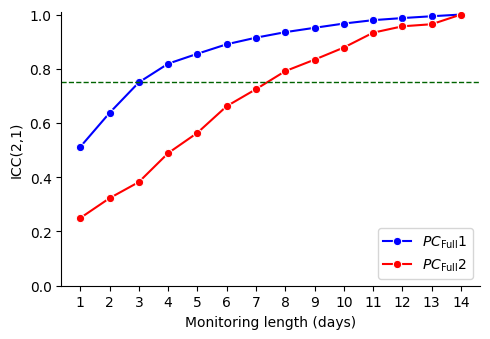

In [19]:
fig, ax = plt.subplots(figsize=(5, 3.5))


palette = {
    "PC1": "blue",
    "PC2": "red",
}

sns.lineplot(
    data=table[table["reference"] == "14day"],
    x="days",
    y="ICC_21",
    hue="PC",
    palette=palette,
    marker="o",
    ax=ax,
)

ax.set(
    xlabel="Monitoring length (days)",
    ylabel="ICC(2,1)",
    ylim=(0, 1),
    xticks=range(1, 15),
)
ax.axhline(0.75, ls="--", lw=1, c="darkgreen")
ax.set_ylim([0,1.01])
ax.legend(title=None)
sns.despine()

legend = ax.legend(title=None, loc="lower right")

label_map = {
    "PC1": r"$PC_{\mathrm{Full}}1$",
    "PC2": r"$PC_{\mathrm{Full}}2$",
}

for text in legend.get_texts():
    text.set_text(label_map.get(text.get_text(), text.get_text()))
    
plt.tight_layout()

plt.savefig(FIGURES_DIR / "panel_3_PC1_PC2_recoverability.svg", format="svg", bbox_inches="tight")
plt.show()

In [20]:
table[(table["PC"]=="PC2") & (table["reference"]=="14day")].round(2)

,reference,days,PC,n,ICC_21,ICC_31,pearson,spearman
29,14day,1,PC2,853,0.25,0.25,0.26,0.24
31,14day,2,PC2,853,0.32,0.32,0.33,0.27
33,14day,3,PC2,853,0.38,0.38,0.41,0.34
35,14day,4,PC2,853,0.49,0.49,0.52,0.45
37,14day,5,PC2,853,0.56,0.56,0.61,0.55
39,14day,6,PC2,853,0.66,0.66,0.69,0.64
41,14day,7,PC2,853,0.72,0.72,0.74,0.71
43,14day,8,PC2,853,0.79,0.79,0.80,0.77
45,14day,9,PC2,853,0.83,0.83,0.84,0.82
47,14day,10,PC2,853,0.88,0.88,0.88,0.86


In [21]:
table[(table["PC"]=="PC1") & (table["reference"]=="full")].round(2)

,reference,days,PC,n,ICC_21,ICC_31,pearson,spearman
0,full,1,PC1,853,0.52,0.52,0.52,0.47
2,full,2,PC1,853,0.64,0.64,0.64,0.62
4,full,3,PC1,853,0.75,0.75,0.75,0.73
6,full,4,PC1,853,0.81,0.81,0.82,0.80
8,full,5,PC1,853,0.85,0.85,0.87,0.84
10,full,6,PC1,853,0.88,0.88,0.90,0.88
12,full,7,PC1,853,0.90,0.90,0.91,0.90
14,full,8,PC1,853,0.93,0.93,0.94,0.92
16,full,9,PC1,853,0.94,0.94,0.95,0.94
18,full,10,PC1,853,0.96,0.96,0.96,0.95


In [22]:
table[(table["PC"]=="PC2") & (table["reference"]=="full")].round(2)

,reference,days,PC,n,ICC_21,ICC_31,pearson,spearman
1,full,1,PC2,853,0.29,0.29,0.30,0.28
3,full,2,PC2,853,0.32,0.32,0.33,0.31
5,full,3,PC2,853,0.38,0.38,0.41,0.37
7,full,4,PC2,853,0.48,0.48,0.52,0.48
9,full,5,PC2,853,0.55,0.55,0.61,0.57
11,full,6,PC2,853,0.65,0.65,0.69,0.66
13,full,7,PC2,853,0.71,0.71,0.73,0.72
15,full,8,PC2,853,0.78,0.78,0.79,0.78
17,full,9,PC2,853,0.82,0.82,0.82,0.82
19,full,10,PC2,853,0.87,0.87,0.87,0.87


In [23]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
table.to_csv(RESULTS_DIR / "PC_score_minimum_days_analysis.csv", index=False)

reference_audit = pd.DataFrame([
    {
        "reference": name,
        "participant_scope": reference["cohort_scope"],
        "n_modelled_meals": reference["scalers"]["n_modelled_meals"],
        "n_participants": reference["scalers"]["n_participants"],
        "max_observed_dates": reference["scalers"]["max_observed_dates"],
    }
    for name, reference in refs.items()
])
#reference_audit.to_csv(
#    RESULTS_DIR / "PC_score_reference_monitoring_length_audit.csv", index=False
#)
display(reference_audit)

,reference,participant_scope,n_modelled_meals,n_participants,max_observed_dates
0,full,all,50463,992,48
1,14day,window,39482,853,14


## 4. Three-day windows versus eleven-day complements

Estimate scores for days 1–3, 4–6, 7–9, and 10–12 and for each window's eleven-day complement within the first fourteen observed dates. Use the same eligible participants and one shared fitted model/PC basis for all comparisons, with six-hour predictor-history and two-hour response boundary exclusions. Summarize agreement across windows and assess bias relative to the complements.

In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm

_CB_COLS = [
    "_cb_start", "_cb_calendar_date", "_cb_day",
    "_cb_available_days", "_cb_capped_days", "_cb_elapsed_days",
]


def prepare_variable_monitoring_horizon(
    data, subject_col=SUBJECT_COL, time_col=DATE_COL,
    min_days=14, max_days=14, verbose=True,
):
    """
    Define monitoring days as ordered UNIQUE OBSERVED CALENDAR DATES.

    Example:
        Jan 1 -> day 1
        Jan 2 -> day 2
        Jan 4 -> day 3

    Participants require >= min_days observed calendar dates.
    Only the first max_days observed dates are retained.
    """
    if min_days < 1:
        raise ValueError("min_days must be >= 1.")
    if max_days < min_days:
        raise ValueError("max_days must be >= min_days.")
    if subject_col not in data.columns:
        raise KeyError(f"{subject_col!r} is not present in data.")
    if time_col not in data.columns:
        raise KeyError(f"{time_col!r} is not present in data.")

    out = data.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out = out.dropna(subset=[subject_col, time_col]).sort_values([subject_col, time_col]).reset_index(drop=True)
    out["_cb_calendar_date"] = out[time_col].dt.normalize()

    # Same logic as ExpandingWindowTrainOnly: unique observed dates -> 1, 2, 3, ...
    out["_cb_day"] = (
        out.groupby(subject_col, sort=False)["_cb_calendar_date"]
        .transform(lambda s: pd.factorize(s, sort=True)[0] + 1)
        .astype(int)
    )

    bounds = out.groupby(subject_col).agg(
        first_time=(time_col, "min"),
        last_time=(time_col, "max"),
        first_calendar_date=("_cb_calendar_date", "min"),
        last_calendar_date=("_cb_calendar_date", "max"),
        n_meals_before_crop=(time_col, "size"),
        available_days=("_cb_calendar_date", "nunique"),
    )
    bounds["available_days"] = bounds["available_days"].astype(int)
    bounds["retained"] = bounds["available_days"] >= min_days
    bounds["capped_days"] = bounds["available_days"].clip(upper=max_days).astype(int)

    eligible = bounds.index[bounds["retained"]]
    out = out[out[subject_col].isin(eligible)].copy()
    out["_cb_start"] = out[subject_col].map(bounds["first_calendar_date"])
    out["_cb_available_days"] = out[subject_col].map(bounds["available_days"]).astype(int)
    out["_cb_capped_days"] = out[subject_col].map(bounds["capped_days"]).astype(int)

    # Hard primary-analysis cap: first 14 observed dates only.
    out = out[out["_cb_day"] <= max_days].sort_values([subject_col, time_col]).reset_index(drop=True)

    meals_after_crop = out.groupby(subject_col).size()
    bounds["n_meals_after_crop"] = meals_after_crop.reindex(bounds.index).fillna(0).astype(int)

    if verbose:
        n_total, n_keep = len(bounds), int(bounds["retained"].sum())
        print(
            f"Calendar-day filter: {n_total} -> {n_keep} participants; "
            f"{n_total - n_keep} removed (< {min_days} observed calendar days)."
        )
        print(
            f"Data restricted to first {max_days} observed calendar days: "
            f"{len(out):,} meals from {out[subject_col].nunique()} participants."
        )

    return out, bounds.reset_index()


def make_independent_window_starts(max_days=14, window_days=3):
    """Complete non-overlapping windows only: for 14 days -> (1, 4, 7, 10)."""
    return tuple(
        start for start in range(1, max_days + 1, window_days)
        if start + window_days - 1 <= max_days
    )


def split_three_days_vs_eleven(
    prepared_data, window_start_day,
    subject_col=SUBJECT_COL, time_col=DATE_COL,
    window_days=3, max_days=14,
    min_meals_3d=5, min_meals_11d=5,
    lookback_hours=6, response_hours=2,
):
    """
    Split one 3-day block against the other 11 observed calendar days
    within the same fixed 14-day frame.
    """
    window_end_day = window_start_day + window_days - 1
    if window_start_day < 1 or window_end_day > max_days:
        raise ValueError("Requested 3-day window falls outside the fixed monitoring frame.")

    required = {subject_col, time_col, "_cb_calendar_date", "_cb_day", "_cb_capped_days"}
    missing = required.difference(prepared_data.columns)
    if missing:
        raise KeyError(f"prepared_data is missing required columns: {sorted(missing)}")

    # For a 3-vs-11 analysis, subjects must possess the complete 14-day frame.
    data = prepared_data[prepared_data["_cb_capped_days"] >= max_days].copy()
    n_window_eligible = data[subject_col].nunique()

    if data.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), {
            "n_window_eligible": 0, "n_meal_eligible": 0
        }

    day_lookup = data[[subject_col, "_cb_day", "_cb_calendar_date"]].drop_duplicates()
    start_dates = day_lookup.loc[
        day_lookup["_cb_day"] == window_start_day
    ].set_index(subject_col)["_cb_calendar_date"]
    end_dates = day_lookup.loc[
        day_lookup["_cb_day"] == window_end_day
    ].set_index(subject_col)["_cb_calendar_date"]

    window_start = data[subject_col].map(start_dates)
    window_end = data[subject_col].map(end_dates) + pd.Timedelta(days=1)
    t = data[time_col]

    in_3d = data["_cb_day"].between(window_start_day, window_end_day)
    keep_3d = in_3d.copy()
    keep_11d = ~in_3d

    lookback = pd.Timedelta(hours=lookback_hours)
    response = pd.Timedelta(hours=response_hours)

    # Protect the left boundary for interior blocks.
    if window_start_day > 1:
        keep_3d &= t >= window_start + lookback
        keep_11d &= ~((t >= window_start - response) & (t < window_start))

    # Protect the right boundary for all four primary blocks.
    if window_end_day < max_days:
        keep_3d &= t < window_end - response
        keep_11d &= ~((t >= window_end) & (t < window_end + lookback))

    data_3d = data.loc[keep_3d].copy()
    data_11d = data.loc[keep_11d].copy()

    participant_info = data.groupby(subject_col).agg(
        available_days_capped=("_cb_capped_days", "first")
    )
    counts_3d = data_3d.groupby(subject_col).agg(
        n_meals_3d=(time_col, "size"),
        n_meal_days_3d=("_cb_day", "nunique"),
    )
    counts_11d = data_11d.groupby(subject_col).agg(
        n_meals_11d=(time_col, "size"),
        n_meal_days_11d=("_cb_day", "nunique"),
    )

    counts = participant_info.join(counts_3d, how="left").join(counts_11d, how="left")
    count_cols = ["n_meals_3d", "n_meal_days_3d", "n_meals_11d", "n_meal_days_11d"]
    counts[count_cols] = counts[count_cols].fillna(0).astype(int)

    counts = counts[
        (counts["n_meals_3d"] >= min_meals_3d) &
        (counts["n_meals_11d"] >= min_meals_11d)
    ].copy()

    eligible = counts.index
    data_3d = data_3d[data_3d[subject_col].isin(eligible)].copy()
    data_11d = data_11d[data_11d[subject_col].isin(eligible)].copy()

    data_3d = data_3d.drop(columns=_CB_COLS, errors="ignore").reset_index(drop=True)
    data_11d = data_11d.drop(columns=_CB_COLS, errors="ignore").reset_index(drop=True)

    counts = counts.reset_index()
    counts["window_start_day"] = window_start_day
    counts["window_end_day"] = window_end_day

    split_info = {
        "n_window_eligible": n_window_eligible,
        "n_meal_eligible": len(counts),
    }
    return data_3d, data_11d, counts, split_info


def run_independent_three_vs_eleven(
    data,
    subject_col=SUBJECT_COL,
    time_col=DATE_COL,
    min_days=14,
    max_days=14,
    window_days=3,
    min_meals_3d=5,
    min_meals_11d=5,
    lookback_hours=6,
    response_hours=2,
    n_job_windows=4,
    n_job=8,
    verbose=True,
):
    """
    Primary reliability analysis.

    Windows:
        days 1-3   vs the other 11 days
        days 4-6   vs the other 11 days
        days 7-9   vs the other 11 days
        days 10-12 vs the other 11 days

    The same participant cohort is used for ALL four analyses.

    Parallelism:
        n_job       = CPUs/threads allocated to the ONE common model fit.
        n_job_windows = number of 3d-vs-11d BLUP/scoring jobs run concurrently.

    A single common model/eigenbasis is deliberate: refitting the same
    14-day cohort four times would be redundant and would make PC axes
    less directly comparable.
    """
    if max_days != 14 or window_days != 3:
        raise ValueError("This primary design is defined for max_days=14 and window_days=3.")
    if min_days < max_days:
        raise ValueError("For the fixed 14-day design, min_days must be >= 14.")

    window_starts = make_independent_window_starts(max_days=max_days, window_days=window_days)
    # For 14 days this is exactly (1, 4, 7, 10).
    if window_starts != (1, 4, 7, 10):
        raise RuntimeError(f"Unexpected primary windows: {window_starts}")

    prepared_data, duration_table = prepare_variable_monitoring_horizon(
        data,
        subject_col=subject_col,
        time_col=time_col,
        min_days=min_days,
        max_days=max_days,
        verbose=verbose,
    )
    if prepared_data.empty:
        raise ValueError("No participants passed the 14-calendar-day filter.")

    # Build all four splits first.
    # Then use the intersection of meal-eligible subjects across ALL four.
    splits = {}
    eligible_sets = []

    for start_day in window_starts:
        data_3d, data_11d, counts, info = split_three_days_vs_eleven(
            prepared_data,
            window_start_day=start_day,
            subject_col=subject_col,
            time_col=time_col,
            window_days=window_days,
            max_days=max_days,
            min_meals_3d=min_meals_3d,
            min_meals_11d=min_meals_11d,
            lookback_hours=lookback_hours,
            response_hours=response_hours,
        )
        splits[start_day] = {
            "data_3d": data_3d,
            "data_11d": data_11d,
            "counts": counts,
            "info": info,
        }
        eligible_sets.append(set(counts[subject_col]))

    common_subjects = set.intersection(*eligible_sets)
    if len(common_subjects) < 3:
        raise ValueError("Fewer than 3 participants satisfy eligibility in all four windows.")

    # Preserve original subject order.
    common_ids = pd.Index(
        [x for x in prepared_data[subject_col].drop_duplicates() if x in common_subjects],
        name=subject_col,
    )

    if verbose:
        print(f"Primary windows: {[f'{s}-{s+2}' for s in window_starts]}")
        print(f"Common meal-eligible cohort across all four windows: {len(common_ids)} participants.")

    # Fit ONE common phenotype model on exactly those subjects' 14 days.
    fit_data = prepared_data[
        prepared_data[subject_col].isin(common_ids)
    ].drop(columns=_CB_COLS, errors="ignore").reset_index(drop=True)

    if verbose:
        print(
            f"Fitting common model on {fit_data[subject_col].nunique()} participants "
            f"and {len(fit_data):,} meals using {n_job} CPUs."
        )

    fitted_result, scalers, fit_info = fit_training_fold(
        fit_data,
        n_jobs_model=n_job,
    )
    eigenvalues, eigenvectors = derive_pc_basis(fitted_result)

    # Infer each independent 3d-vs-11d pair in parallel.
    # Threads avoid copying the potentially large frozen fitted model.
    def _score_window(start_day):
        payload = splits[start_day]
        end_day = start_day + window_days - 1

        data_3d = payload["data_3d"]
        data_11d = payload["data_11d"]
        counts = payload["counts"]

        data_3d = data_3d[data_3d[subject_col].isin(common_ids)].reset_index(drop=True)
        data_11d = data_11d[data_11d[subject_col].isin(common_ids)].reset_index(drop=True)
        counts = counts[counts[subject_col].isin(common_ids)].copy()

        blup_3d = infer_blups_from_frozen_model(fitted_result, data_3d, scalers)
        blup_11d = infer_blups_from_frozen_model(fitted_result, data_11d, scalers)

        common = blup_3d.index.intersection(blup_11d.index)
        blup_3d = blup_3d.loc[common]
        blup_11d = blup_11d.loc[common]

        if list(blup_3d.columns) != list(blup_11d.columns):
            raise RuntimeError(f"BLUP coordinate order differs for days {start_day}-{end_day}.")

        scores_3d = project_blups_to_pcs(
            blup_3d, eigenvalues, eigenvectors,
            n_components=2, standardize=True,
        )
        scores_11d = project_blups_to_pcs(
            blup_11d, eigenvalues, eigenvectors,
            n_components=2, standardize=True,
        )

        scores = scores_3d.add_suffix("_3d").join(scores_11d.add_suffix("_11d")).reset_index()
        index_name = blup_3d.index.name or "index"
        scores = scores.rename(columns={index_name: subject_col})
        scores["fold"] = start_day
        scores["window_start_day"] = start_day
        scores["window_end_day"] = end_day
        scores = scores.merge(
            counts,
            on=[subject_col, "window_start_day", "window_end_day"],
            how="left",
        )

        diag = {
            "window_start_day": start_day,
            "window_end_day": end_day,
            "n_duration_eligible": prepared_data[subject_col].nunique(),
            "n_window_eligible": payload["info"]["n_window_eligible"],
            "n_meal_eligible_before_common": payload["info"]["n_meal_eligible"],
            "n_common_before_blup": len(common_ids),
            "n_scored_before_final_intersection": len(scores),
            "median_meals_3d": counts["n_meals_3d"].median(),
            "median_meals_11d": counts["n_meals_11d"].median(),
        }
        return scores, diag

    if verbose:
        print(f"Scoring {len(window_starts)} windows with {n_job_windows} concurrent workers.")

    gen = Parallel(
        n_jobs=n_job_windows,
        prefer="threads",
        return_as="generator",
    )(
        delayed(_score_window)(start_day)
        for start_day in window_starts
    )

    results = list(tqdm(
        gen,
        total=len(window_starts),
        desc="3d vs 11d windows",
        unit="window",
        disable=not verbose,
    ))

    score_parts = [x[0] for x in results]
    diagnostics = [x[1] for x in results]

    # Second intersection AFTER BLUP inference.
    # This guarantees exactly the same final subjects in every ICC.
    scored_sets = [set(frame[subject_col]) for frame in score_parts]
    final_common = set.intersection(*scored_sets)

    if len(final_common) < 3:
        raise ValueError("Fewer than 3 participants have valid BLUP scores in all four windows.")

    score_parts = [
        frame[frame[subject_col].isin(final_common)].copy()
        for frame in score_parts
    ]

    for diag in diagnostics:
        diag["n_final_common_scored"] = len(final_common)

    scores = pd.concat(score_parts, ignore_index=True)

    # Strong balance check: every subject must appear once in each of 4 windows.
    n_windows_per_subject = scores.groupby(subject_col)["window_start_day"].nunique()
    if not (n_windows_per_subject == len(window_starts)).all():
        raise RuntimeError("Final score table is not balanced across the four windows.")

    positive_eigenvalues = np.clip(eigenvalues, 0, None)
    variance_fraction = positive_eigenvalues / positive_eigenvalues.sum()

    loading_table = pd.DataFrame({
        "coordinate": score_parts[0].filter(regex="^$").columns  # replaced below
    })
    # Use BLUP coordinate names directly from one fresh common-window inference result.
    first_start = window_starts[0]
    first_data = splits[first_start]["data_3d"]
    first_data = first_data[first_data[subject_col].isin(final_common)].reset_index(drop=True)
    first_blup = infer_blups_from_frozen_model(fitted_result, first_data, scalers)

    loading_table = pd.DataFrame({
        "coordinate": first_blup.columns,
        "PC1": eigenvectors[:, 0],
        "PC2": eigenvectors[:, 1],
    })

    fit_info = dict(fit_info)
    fit_info.update({
        "min_days": min_days,
        "max_days": max_days,
        "window_starts": window_starts,
        "day_definition": "ordered_unique_observed_calendar_dates",
        "n_common_meal_eligible": len(common_ids),
        "n_final_common_scored": len(final_common),
        "pc1_variance_fraction": variance_fraction[0],
        "pc2_variance_fraction": variance_fraction[1],
    })

    return {
        "scores": scores,
        "diagnostics": pd.DataFrame(diagnostics),
        "loadings": loading_table,
        "duration_table": duration_table,
        "fit_info": fit_info,
        "eigenvalues": positive_eigenvalues,
        "window_starts": window_starts,
        "common_subjects": pd.Index(sorted(final_common)),
    }


def summarize_independent_three_vs_eleven(
    scores, pcs=("PC1", "PC2"), n_boot=1000, random_state=42,
):
    """
    Run the existing 3-vs-11 summary separately for:
        days 1-3, 4-6, 7-9, 10-12.
    """
    results = {}

    for (start_day, end_day), block in scores.groupby(
        ["window_start_day", "window_end_day"], sort=True
    ):
        results[f"days_{int(start_day)}_{int(end_day)}"] = summarize_three_vs_eleven(
            block,
            pcs=pcs,
            n_boot=n_boot,
            random_state=random_state,
        )

    return results

import numpy as np
import pandas as pd
import pingouin as pg
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests


def _extract_icc(icc_table, kind="absolute", average=False):
    """Extract ICC and its CI across the old/new Pingouin column conventions."""
    if kind == "absolute":
        labels = ["ICC2k", "ICC(A,k)"] if average else ["ICC2", "ICC(A,1)"]
    elif kind == "consistency":
        labels = ["ICC3k", "ICC(C,k)"] if average else ["ICC3", "ICC(C,1)"]
    else:
        raise ValueError("kind must be 'absolute' or 'consistency'.")
    selected = icc_table.loc[icc_table["Type"].isin(labels)]
    if len(selected) != 1:
        raise ValueError(f"Expected one ICC row for {labels}.")
    ci_column = next((key for key in ("CI95", "CI95%") if key in selected), None)
    if ci_column is None:
        raise ValueError("No CI95 or CI95% column in Pingouin ICC output.")
    row = selected.iloc[0]
    ci = np.asarray(row[ci_column], dtype=float)
    if ci.shape != (2,):
        raise ValueError("ICC confidence interval must contain two bounds.")
    return float(row["ICC"]), float(ci[0]), float(ci[1])




def _icc_long(long, targets, raters, ratings):
    """Return absolute-agreement and consistency ICCs from a complete long-format table."""
    icc = pg.intraclass_corr(data=long, targets=targets, raters=raters, ratings=ratings)
    a1, a1_lo, a1_hi = _extract_icc(icc, "absolute", average=False)
    c1, c1_lo, c1_hi = _extract_icc(icc, "consistency", average=False)
    ak, ak_lo, ak_hi = _extract_icc(icc, "absolute", average=True)
    ck, ck_lo, ck_hi = _extract_icc(icc, "consistency", average=True)
    return {
        "ICC_A1": a1, "ICC_A1_CI_low": a1_lo, "ICC_A1_CI_high": a1_hi,
        "ICC_C1": c1, "ICC_C1_CI_low": c1_lo, "ICC_C1_CI_high": c1_hi,
        "ICC_Ak": ak, "ICC_Ak_CI_low": ak_lo, "ICC_Ak_CI_high": ak_hi,
        "ICC_Ck": ck, "ICC_Ck_CI_low": ck_lo, "ICC_Ck_CI_high": ck_hi,
    }


def analyze_three_day_reliability(scores, subject_col="subject_key", pcs=("PC1", "PC2")):
    """
    ICC across the four independent 3-day estimates:
        days 1-3, 4-6, 7-9, 10-12.

    ICC_A1: absolute agreement of ONE arbitrary 3-day estimate.
    ICC_C1: consistency/rank reproducibility of ONE 3-day estimate.
    ICC_Ak/Ck: reliability of the AVERAGE of all four 3-day estimates.
    """
    expected_windows = (1, 4, 7, 10)
    observed_windows = tuple(sorted(scores["window_start_day"].unique()))

    if observed_windows != expected_windows:
        raise ValueError(f"Expected windows {expected_windows}, found {observed_windows}.")

    # Require the exact same subjects in every 3-day window.
    sets = [
        set(scores.loc[scores["window_start_day"] == w, subject_col])
        for w in expected_windows
    ]
    common = set.intersection(*sets)

    rows = []
    for pc in pcs:
        tmp = scores[scores[subject_col].isin(common)][
            [subject_col, "window_start_day", f"{pc}_3d"]
        ].dropna().copy()

        counts = tmp.groupby(subject_col)["window_start_day"].nunique()
        complete = counts.index[counts == len(expected_windows)]
        tmp = tmp[tmp[subject_col].isin(complete)]

        long = tmp.rename(columns={"window_start_day": "window", f"{pc}_3d": "score"})
        metrics = _icc_long(long, targets=subject_col, raters="window", ratings="score")

        rows.append({
            "PC": pc,
            "n_subjects": len(complete),
            "n_windows": len(expected_windows),
            **metrics,
        })

    return pd.DataFrame(rows)


def analyze_three_vs_eleven(scores, subject_col="subject_key", pcs=("PC1", "PC2")):
    """
    Agreement between each 3-day estimate and its OWN complementary 11-day estimate.

    Returns one row per PC x window with:
      * absolute-agreement ICC
      * consistency ICC
      * Pearson r
      * Spearman rho
      * mean difference (3d - 11d)
      * MAE / RMSE
      * Bland-Altman 95% limits of agreement
    """
    rows = []

    for (start, end), block in scores.groupby(["window_start_day", "window_end_day"], sort=True):
        for pc in pcs:
            x = block[f"{pc}_3d"].to_numpy(dtype=float)
            y = block[f"{pc}_11d"].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            ids = block.loc[mask, subject_col].to_numpy()
            n = len(x)

            rec = {
                "PC": pc,
                "window": f"{int(start)}-{int(end)}",
                "window_start_day": int(start),
                "window_end_day": int(end),
                "n": n,
            }

            if n < 3:
                rec.update({
                    "ICC_A1": np.nan, "ICC_A1_CI_low": np.nan, "ICC_A1_CI_high": np.nan,
                    "ICC_C1": np.nan, "ICC_C1_CI_low": np.nan, "ICC_C1_CI_high": np.nan,
                    "pearson": np.nan, "pearson_p": np.nan,
                    "pearson_CI_low": np.nan, "pearson_CI_high": np.nan,
                    "spearman": np.nan, "spearman_p": np.nan,
                    "bias_3d_minus_11d": np.nan, "MAE": np.nan, "RMSE": np.nan,
                    "BA_lower": np.nan, "BA_upper": np.nan,
                })
                rows.append(rec)
                continue

            long = pd.DataFrame({
                subject_col: np.r_[ids, ids],
                "method": ["3d"] * n + ["11d"] * n,
                "score": np.r_[x, y],
            })
            icc = _icc_long(long, targets=subject_col, raters="method", ratings="score")

            pr = pearsonr(x, y)
            try:
                pci = pr.confidence_interval(confidence_level=0.95)
                pearson_lo, pearson_hi = float(pci.low), float(pci.high)
            except Exception:
                pearson_lo, pearson_hi = np.nan, np.nan

            sr = spearmanr(x, y)
            diff = x - y
            bias = diff.mean()
            sd_diff = diff.std(ddof=1)

            rec.update({
                "ICC_A1": icc["ICC_A1"],
                "ICC_A1_CI_low": icc["ICC_A1_CI_low"],
                "ICC_A1_CI_high": icc["ICC_A1_CI_high"],
                "ICC_C1": icc["ICC_C1"],
                "ICC_C1_CI_low": icc["ICC_C1_CI_low"],
                "ICC_C1_CI_high": icc["ICC_C1_CI_high"],
                "pearson": float(pr.statistic),
                "pearson_p": float(pr.pvalue),
                "pearson_CI_low": pearson_lo,
                "pearson_CI_high": pearson_hi,
                "spearman": float(sr.statistic),
                "spearman_p": float(sr.pvalue),
                "bias_3d_minus_11d": float(bias),
                "MAE": float(np.mean(np.abs(diff))),
                "RMSE": float(np.sqrt(np.mean(diff ** 2))),
                "BA_lower": float(bias - 1.96 * sd_diff),
                "BA_upper": float(bias + 1.96 * sd_diff),
            })
            rows.append(rec)

    out = pd.DataFrame(rows)

    # FDR correction because there are 4 windows x 2 PCs.
    valid = out["pearson_p"].notna()
    out.loc[valid, "pearson_p_FDR"] = multipletests(
        out.loc[valid, "pearson_p"], method="fdr_bh"
    )[1]

    valid = out["spearman_p"].notna()
    out.loc[valid, "spearman_p_FDR"] = multipletests(
        out.loc[valid, "spearman_p"], method="fdr_bh"
    )[1]

    return out


def analyze_subject_level_three_day_stability(
    scores, subject_col="subject_key", pcs=("PC1", "PC2")
):
    """
    Optional descriptive analysis: how much each participant's 3-day score
    moves across the four independent windows.
    """
    parts = []

    for pc in pcs:
        wide = scores.pivot(
            index=subject_col,
            columns="window_start_day",
            values=f"{pc}_3d",
        )

        wide = wide[[1, 4, 7, 10]].dropna()
        tmp = pd.DataFrame({
            subject_col: wide.index,
            "PC": pc,
            "mean_3d_score": wide.mean(axis=1).values,
            "within_subject_SD": wide.std(axis=1, ddof=1).values,
            "within_subject_range": (wide.max(axis=1) - wide.min(axis=1)).values,
        })
        parts.append(tmp)

    subject_level = pd.concat(parts, ignore_index=True)

    summary = (
        subject_level.groupby("PC")
        .agg(
            n=(subject_col, "size"),
            median_within_subject_SD=("within_subject_SD", "median"),
            mean_within_subject_SD=("within_subject_SD", "mean"),
            median_range=("within_subject_range", "median"),
            mean_range=("within_subject_range", "mean"),
        )
        .reset_index()
    )

    return subject_level, summary


def run_posthoc_three_vs_eleven(
    within_result,
    subject_col="subject_key",
    pcs=("PC1", "PC2"),
):
    """Run the complete post-hoc analysis from run_independent_three_vs_eleven()."""
    scores = within_result["scores"].copy()

    three_day_reliability = analyze_three_day_reliability(
        scores,
        subject_col=subject_col,
        pcs=pcs,
    )

    three_vs_eleven = analyze_three_vs_eleven(
        scores,
        subject_col=subject_col,
        pcs=pcs,
    )

    subject_stability, subject_stability_summary = (
        analyze_subject_level_three_day_stability(
            scores,
            subject_col=subject_col,
            pcs=pcs,
        )
    )

    return {
        "three_day_reliability": three_day_reliability,
        "three_vs_eleven": three_vs_eleven,
        "subject_stability": subject_stability,
        "subject_stability_summary": subject_stability_summary,
        "diagnostics": within_result.get("diagnostics"),
    }

In [ ]:
within_result = run_independent_three_vs_eleven(
    data=data_uncapped,
    subject_col="subject_key",
    time_col="eaten_at",   # use the real timestamp if using 6h/2h boundary protection
    min_days=14,
    max_days=14,
    window_days=3,
    min_meals_3d=0,
    min_meals_11d=0,
    lookback_hours=6,
    response_hours=2,
    n_job_windows=5,       # 4 windows can be scored concurrently
    n_job=6,               # CPUs used by the ONE common phenotype-model fit
    verbose=True,
)

display(within_result["diagnostics"])
within_scores = within_result["scores"]

In [ ]:
posthoc = run_posthoc_three_vs_eleven(
    within_result,
    subject_col="subject_key",
    pcs=("PC1", "PC2"),
)

display(posthoc["three_day_reliability"])

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2


def analyze_mixed_three_vs_eleven(
    scores,
    subject_col="subject_key",
    pcs=("PC1", "PC2"),
):
    results = {}
    
    for pc in pcs:
        df = scores[
            [
                subject_col,
                "window_start_day",
                f"{pc}_3d",
                f"{pc}_11d",
            ]
        ].dropna().copy()

        df["window"] = pd.Categorical(
            df["window_start_day"],
            categories=[1, 4, 7, 10],
        )

        # Main quantity for agreement
        df["difference"] = df[f"{pc}_3d"] - df[f"{pc}_11d"]

        # Bland-Altman x-axis / proportional-bias diagnostic
        df["pair_mean"] = (
            df[f"{pc}_3d"] + df[f"{pc}_11d"]
        ) / 2

        # 1. Overall bias, allowing repeated observations by subject
        overall = smf.mixedlm(
            "difference ~ 1",
            data=df,
            groups=df[subject_col],
        ).fit(reml=False)

        # 2. Does bias depend on WHICH 3-day window was selected?
        by_window = smf.mixedlm(
            "difference ~ C(window)",
            data=df,
            groups=df[subject_col],
        ).fit(reml=False)

        # Likelihood-ratio test for a window effect
        lr = 2 * (by_window.llf - overall.llf)
        df_test = (
            len(by_window.fe_params)
            - len(overall.fe_params)
        )
        p_window = chi2.sf(lr, df_test)

        # 3. Proportional bias:
        #    does disagreement depend on score magnitude?
        proportional = smf.mixedlm(
            "difference ~ pair_mean + C(window)",
            data=df,
            groups=df[subject_col],
        ).fit(reml=False)

        results[pc] = {
            "data": df,
            "overall_bias_model": overall,
            "window_bias_model": by_window,
            "proportional_bias_model": proportional,
            "window_effect_LR": lr,
            "window_effect_df": df_test,
            "window_effect_p": p_window,
        }

    return results

In [ ]:
mixed = analyze_mixed_three_vs_eleven(within_scores)

mixed["PC1"]["overall_bias_model"].summary()
mixed["PC1"]["window_bias_model"].summary()
mixed["PC1"]["proportional_bias_model"].summary()